# Cement Manufacturing Dataset
## by HAMZAT ABDULRAHMAN

## Table of Contents


#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib import rcParams

%matplotlib inline

### Data Gathering

In [2]:
concrete = pd.read_csv("concrete.csv")
concrete.head(5)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


### Assessing

In [3]:
concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [4]:
concrete.duplicated().sum()

25

In [5]:
concrete.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
concrete.isna().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [7]:
concrete['age'].isna().sum()

0

In [8]:
concrete.sample(5)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
207,190.0,190.0,0.0,228.0,0.0,932.0,670.0,180,46.93
430,173.8,93.4,159.9,172.3,9.7,1007.2,746.6,3,15.82
837,181.4,0.0,167.0,169.6,7.6,1055.6,777.8,56,35.57
1015,298.0,0.0,107.0,186.0,6.0,879.0,815.0,28,42.64
944,153.0,102.0,0.0,192.0,0.0,888.0,943.1,28,17.96


### Quality Issues:
1. There are 25 duplicate rows.

### Data Cleaning

In [9]:
# make a copy of dataframe
concrete_clean = concrete.copy()

#### Define:
Remove duplicated rows using `drop_duplicates()` function

#### code:

In [10]:
concrete_clean = concrete_clean.drop_duplicates()

#### Test

In [11]:
concrete_clean.duplicated().sum()

0

# Exploratory Analysis

## Univariate Exploration

#### Question:
How does the distribution of "strength" of concrete looks?

#### Visualization

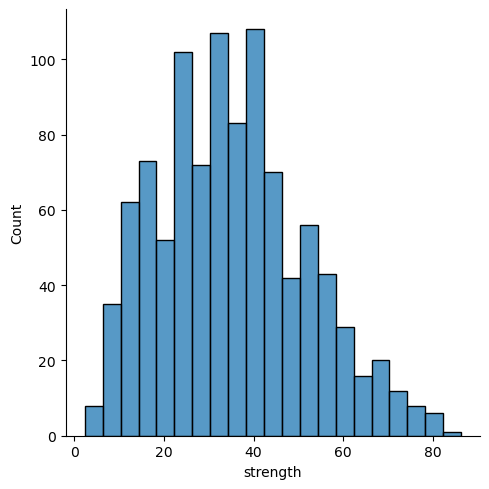

In [12]:
bin_edges = np.arange(concrete_clean['strength'].min(),concrete_clean['strength'].max() + 4, 4)
sb.displot(concrete_clean['strength'], bins = bin_edges);

#### Observation:
Approximately normal distribution. Strengths lower than about 45 have the highest frequency.

#### Question:
How does the distribution of "cement" used for concrete looks?

#### Visualization

In [13]:
np.log10(concrete_clean['cement'].min())

2.0086001717619175

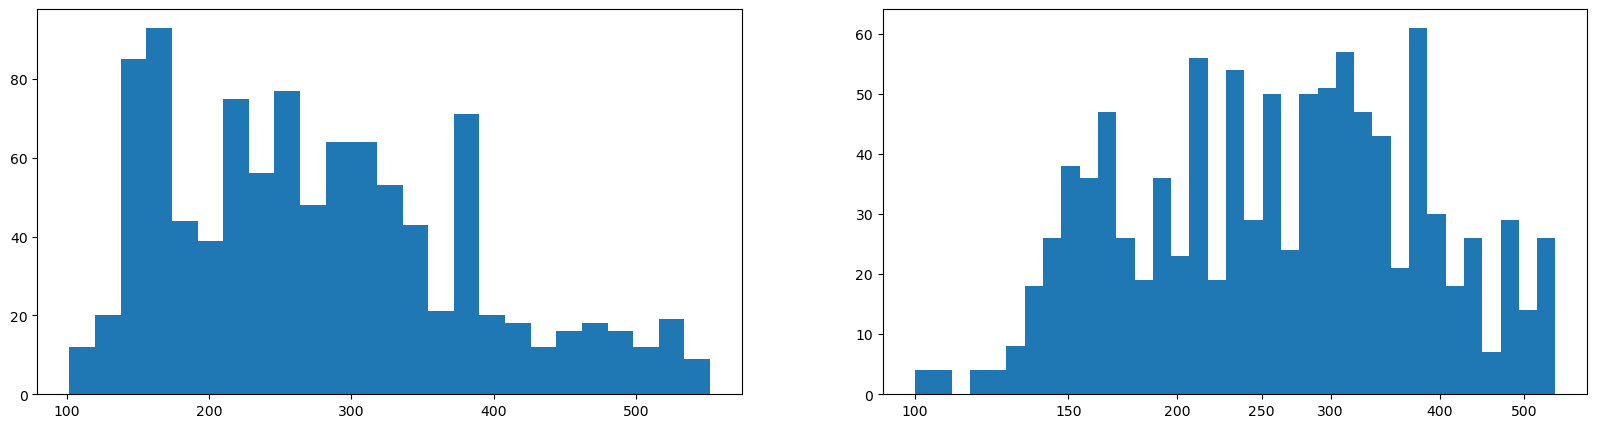

In [14]:
plt.figure(figsize=[20,5])

plt.subplot(1,2,1)
bin_edges = np.arange(102.0,540 +18,18)
plt.hist(data=concrete_clean, x='cement', bins = bin_edges);

plt.subplot(1,2,2)
ticks = [100,150,200,250,300,400,500]
labels = ['{}'.format(v) for v in ticks]
bin_edges = 10**np.arange(2.0,2.73+0.021,0.021)
plt.hist(data=concrete_clean, x='cement', bins = bin_edges)
plt.xscale('log')
plt.xticks(ticks,labels);

#### Observation
The plot initial plot shows a slightly right-skewed with unsual multiple peaks, while the log transform plot shows successive rise and fall in frequency

#### Question:

#### Visualization

In [15]:
concrete_clean['slag'].value_counts()[0]

470

In [16]:
0 in concrete_clean['slag'].values

True

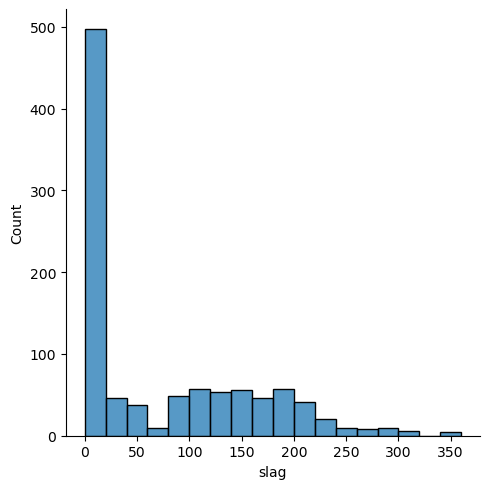

In [17]:
bin_edge = np.arange(concrete_clean['slag'].min(),concrete_clean['slag'].max()+20,20)
sb.displot(concrete_clean['slag'], bins=bin_edge);

#### Observation: 
An extremely tall bar at the zero value which tells that slag is not often used in making concretes.

#### Question:

#### Visualization

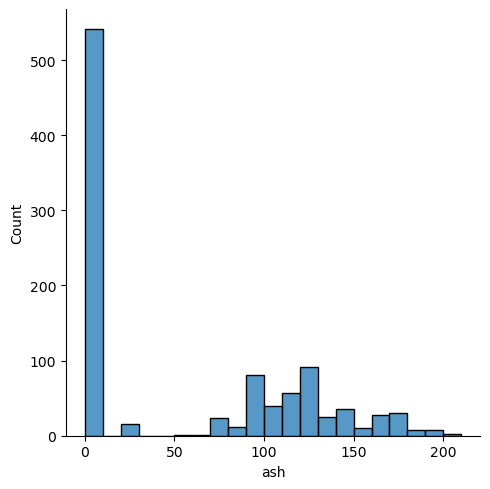

In [18]:
bin_edge = np.arange(concrete_clean['ash'].min(),concrete_clean['ash'].max()+10,10)
sb.displot(concrete_clean['ash'], bins=bin_edge);

#### Observation:
An approximately normal distribution with outliers at the extreme left hand side of the plot - which shows that ash is usually not used when making concretes.

#### Question:

#### Visualization

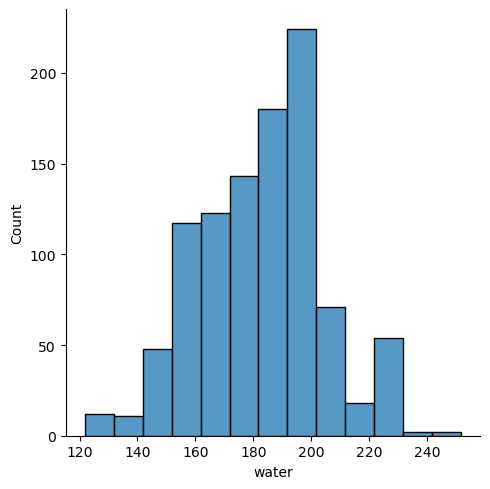

In [19]:
bin_edge = np.arange(concrete_clean['water'].min(),concrete_clean['water'].max()+10,10)
sb.displot(concrete_clean['water'], bins=bin_edge);

#### Observation:
The volumes of water used gives a normally distribution. There are less often the usage of water in quantities above 200 

#### Question:

#### Visualization

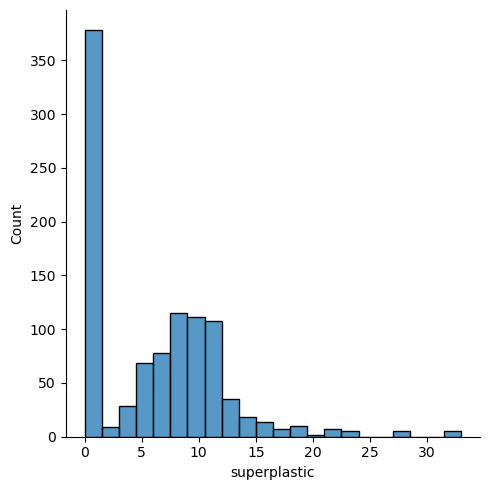

In [20]:
bin_edge = np.arange(concrete_clean['superplastic'].min(),concrete_clean['superplastic'].max()+1.5,1.5)
sb.displot(concrete_clean['superplastic'], bins=bin_edge);

#### Observation: 
This plot also suggest that superplastic, more often than not, is usually not used to make concretes. And its usage gives a right skewed distribution.

#### Question:

#### Visualization

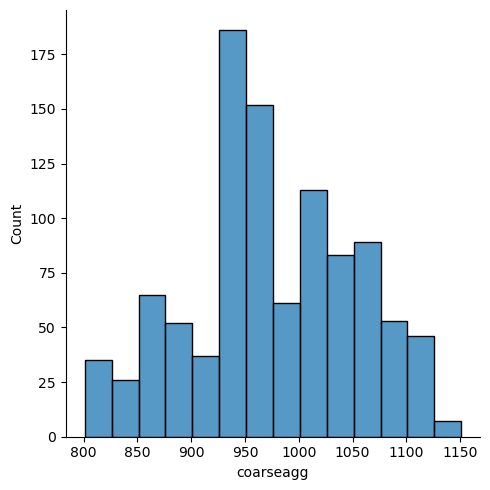

In [21]:
bin_edge = np.arange(concrete_clean['coarseagg'].min(),concrete_clean['coarseagg'].max()+25,25)
sb.displot(concrete_clean['coarseagg'], bins=bin_edge);

#### Observation:
The plot shows that coarseagg is often used in large quantites above 925.

#### Question:

#### Visualization

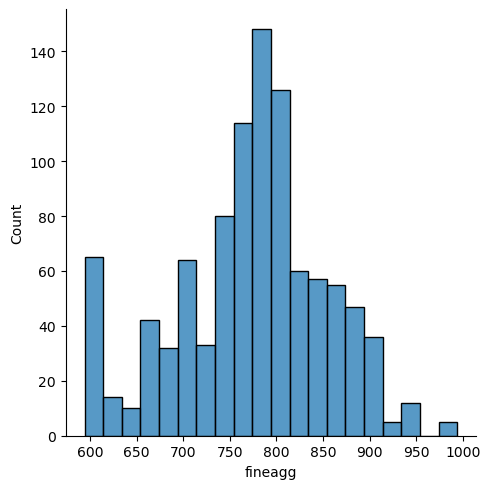

In [22]:
bin_edge = np.arange(concrete_clean['fineagg'].min(),concrete_clean['fineagg'].max()+20,20)
sb.displot(concrete_clean['fineagg'], bins=bin_edge);

#### Observation:

#### Question:

#### Visualization

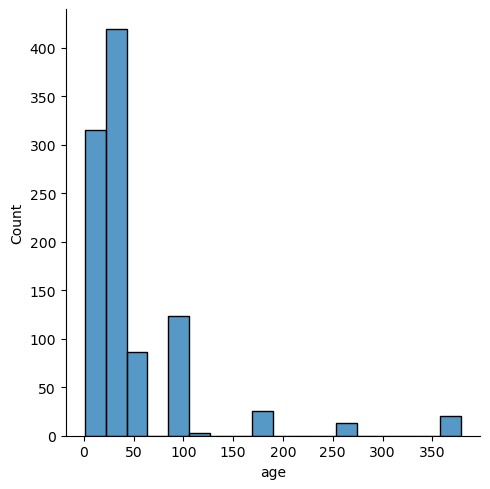

In [23]:
bin_edge = np.arange(concrete_clean['age'].min(),concrete_clean['age'].max()+21,21)
sb.displot(concrete_clean['age'], bins=bin_edge);

#### Observation:
Most concrete mix were left to set in the first 3 weeks,more in the second 3 weeks, followed by the third 3 weeks. Very few mix were left  to set for days greater than 100.

## Bivariate Exploration

#### Question:
Strength vs cement

#### Visualization

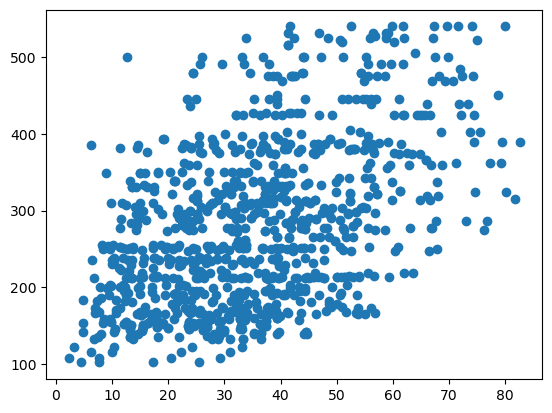

In [24]:
plt.scatter(data=concrete_clean,x='strength',y='cement');

#### Observation:
There is a linear relationship between the amount of cement, and strength of concrete. The higher the cement, the higher the strength of concrete.

#### Question:
Strength vs slag

#### Visualization

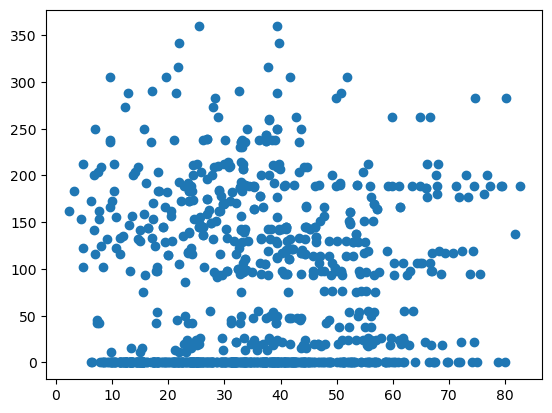

In [25]:
plt.scatter(data=concrete_clean,x='strength',y='slag');

#### Observation:
No relationship is observed.

#### Question:
Strength vs ash

#### Visualization

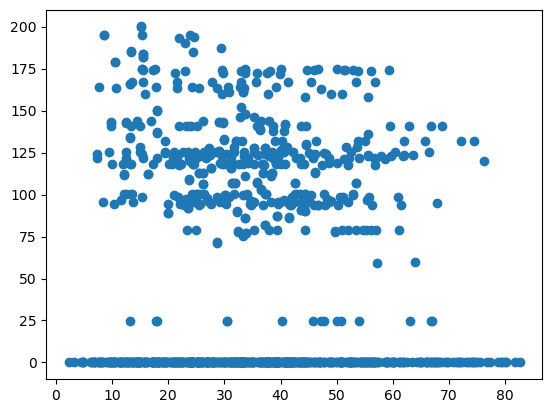

In [26]:
plt.scatter(data=concrete_clean,x='strength',y='ash');

#### Observation:
No meaningful relationship is observed

#### Question:
Strength vs water

#### Visualization

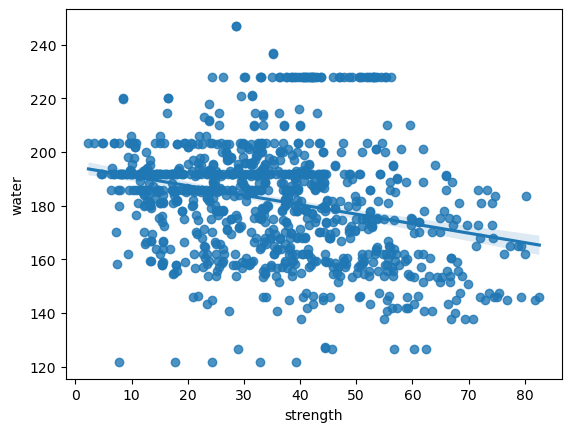

In [27]:
sb.regplot(data=concrete_clean,x='strength',y='water');

#### Observation:
The higher the amount of water, the lower the strength of concrete.

#### Question:
'Strength' vs 'Superplastic'

#### Visualization

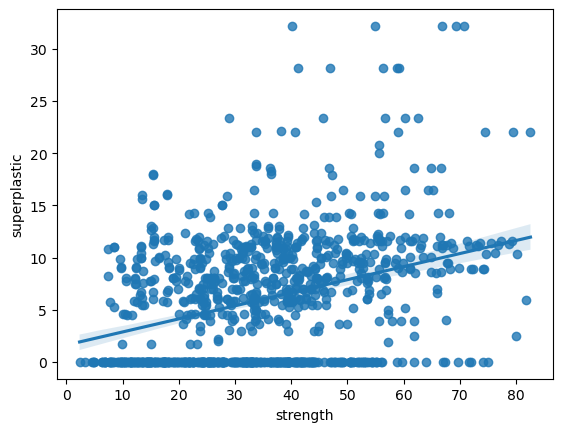

In [28]:
sb.regplot(data=concrete_clean,x='strength',y='superplastic');

#### Observation
A slight relationship is observed - the more the superplastic, the higher the strength.

#### Question:
'Strength' vs 'coarseagg'

#### Visualization

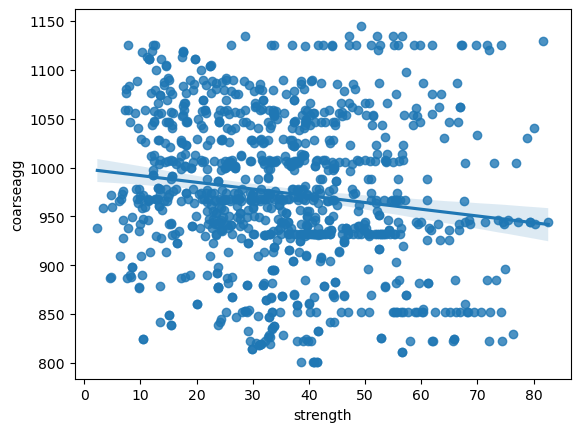

In [29]:
sb.regplot(data=concrete_clean,x='strength',y='coarseagg');

#### Observation:

#### Question:
'Strength' vs 'fineagg'

#### Visualization

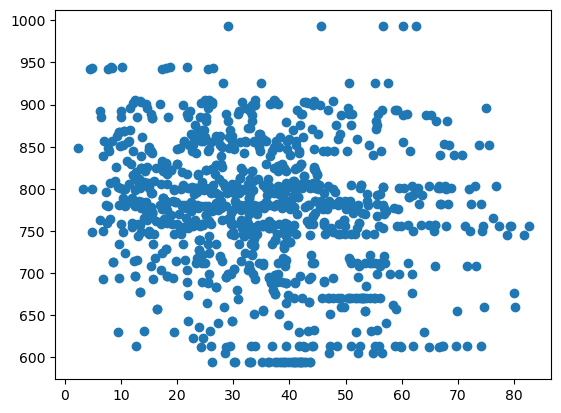

In [38]:
plt.scatter(data=concrete_clean,x='strength',y='fineagg');

#### Observation:
No relationship is observed

#### Question:
'Strength' Vs 'age'

#### Visualization

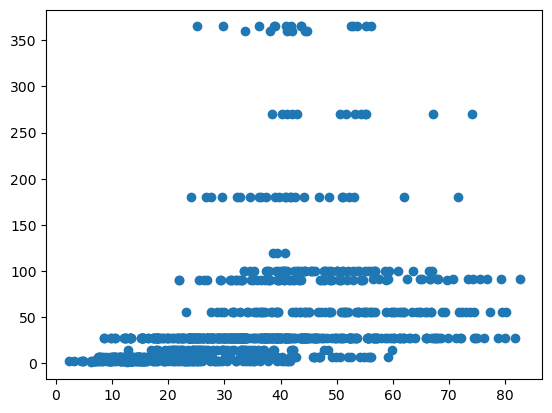

In [31]:
plt.scatter(data=concrete_clean,x='strength',y='age');

#### Observation:
High strength for concrete (above 60) started at an age greater than about 20days. No strength lesser than 23 was observed above 50 days.

I'll be checking to see if there's an insight to derive from the above variables that have a direct relationship with strength. The first will be 'cement' against 'water' 

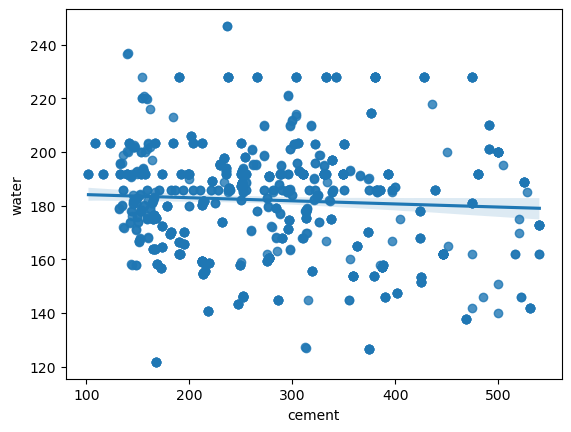

In [32]:
sb.regplot(data=concrete_clean,x='cement',y='water');

No linear relationship is observed. Next is 'age' against 'water'

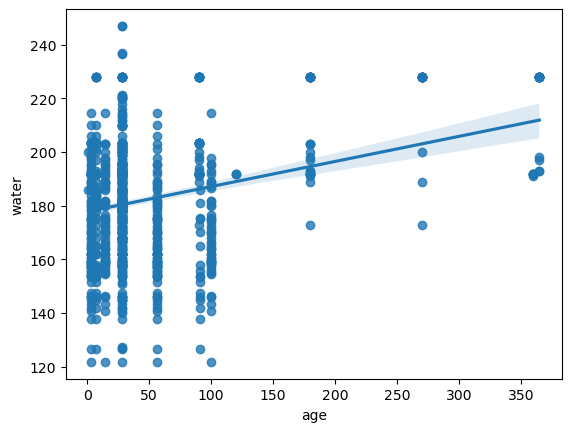

In [33]:
sb.regplot(data=concrete_clean,x='age',y='water');

Below age of 100,there seems to be no correlation between age and water.Above the age of about 185,  it shows that a high volume of water had been added.

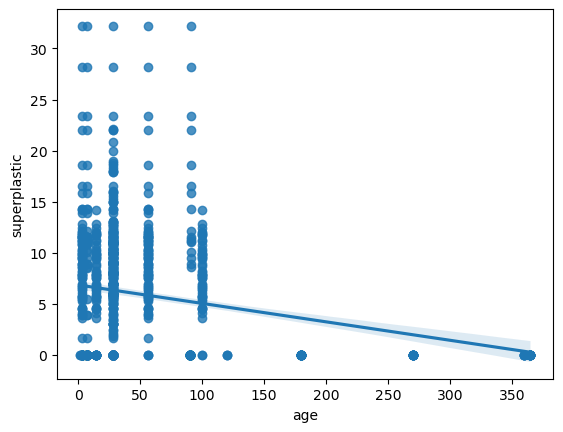

In [34]:
sb.regplot(data=concrete_clean,x='age',y='superplastic');

#### Observation:
No relationship is observed

#### Question:
Is there any relationship between 'cement' and 'superplastic'?

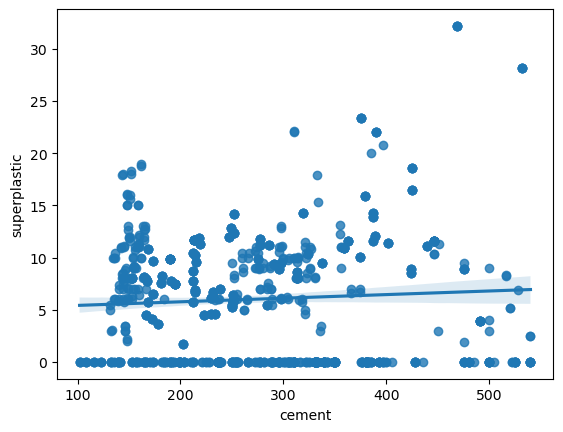

In [35]:
sb.regplot(data=concrete_clean,x='cement',y='superplastic');

#### Observation:
No relationship is observed.

#### Question:
Does amount of cement influences the age?

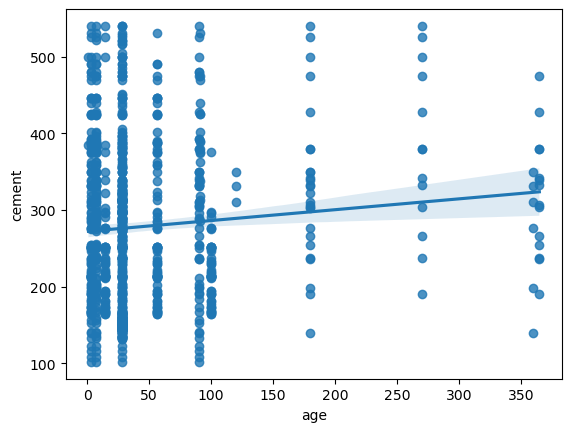

In [36]:
sb.regplot(data=concrete_clean,x='age',y='cement');

Cement and age neither dependent on one another.

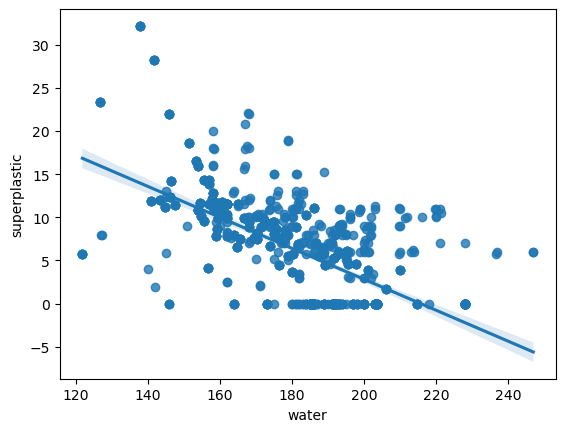

In [39]:
sb.regplot(data=concrete_clean,x='water',y='superplastic');

The more the superplastic, the lesser the volume of water required.

## Multivariate Exploration

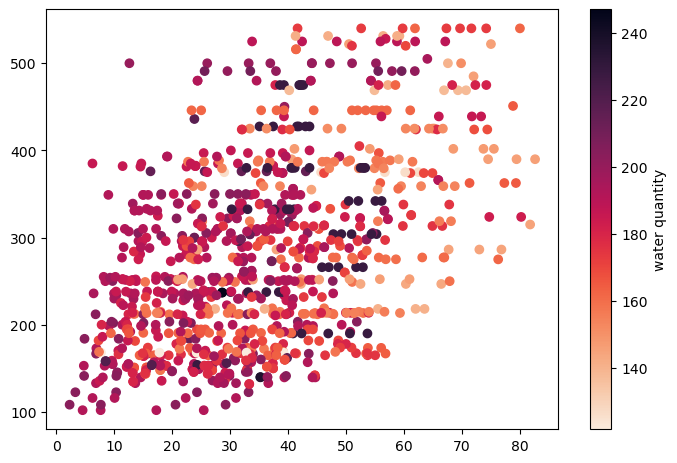

In [50]:
fig_obj = plt.figure()
ax_obj = fig_obj.add_axes([0.125,0.125,1.0,0.875])

plot = ax_obj.scatter(data=concrete_clean, x='strength',y='cement',c='water',cmap='rocket_r')
fig_obj.colorbar(plot,label='water quantity',ax=ax_obj);

#### Observation:
A Large amount of cement with less amount of water resulted in higher strength - around '60-80 Mpa'. While lesser amount of cement but with high quantity of water yielded lower strength.

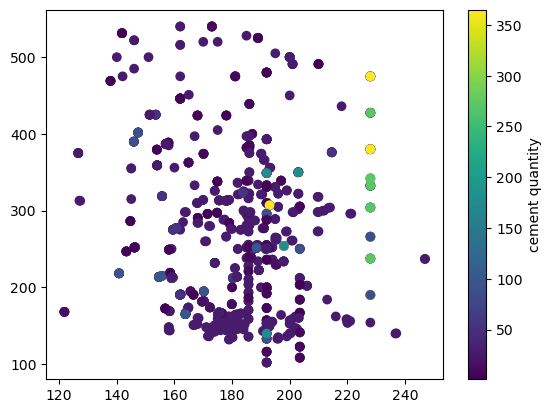

In [61]:
plt.scatter(data=concrete_clean, x='water',y='cement',c='age')
plt.colorbar(label='cement quantity');

Irrespective of the quantity of cement or water, the large majority of age between 0-50 days.

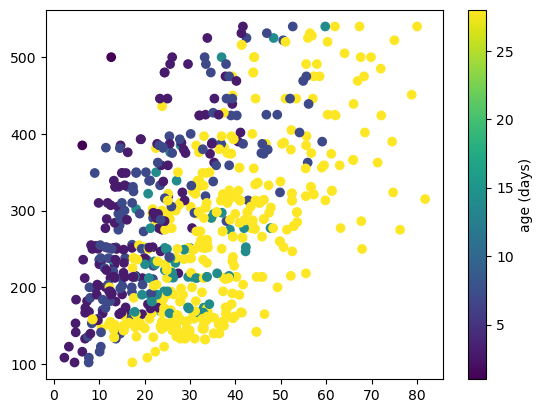

In [65]:
age_clean = concrete_clean.query('age <= 50.0')
plt.scatter(data=age_clean, x='strength',y='cement',c='age')
plt.colorbar(label='age (days)');

The above plot shows that given the same quantity of cement,if the mix is left to set for a higher number of days, the strength of the concrete is improved.